# Random Forest Model

In [ ]:
!pip install pyspark matplotlib seaborn pandas

from pyspark.sql import SparkSession
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler, PCA
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

spark = SparkSession.builder \
    .appName("Swasthya-Matrix-Training") \
    .getOrCreate()

print("Spark Session created successfully!")

Spark Session created successfully!


Random Forest Accuracy: 98.55%
Random Forest F1-Score: 0.9855


/tmp/ipython-input-1612/3680551471.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis")


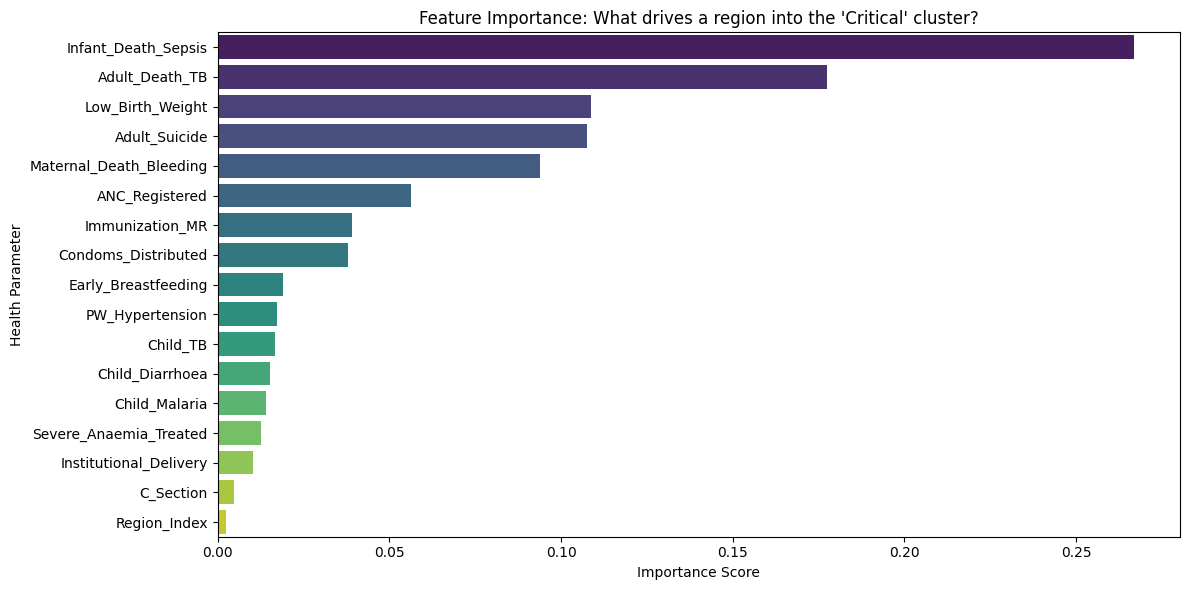

In [ ]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

labeled_data = final_model.transform(df_scaled)

rf_data = labeled_data.withColumnRenamed("prediction", "label")

train_data, test_data = rf_data.randomSplit([0.8, 0.2], seed=42)

rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=50, maxDepth=5, seed=42)
rf_model = rf.fit(train_data)

rf_predictions = rf_model.transform(test_data)

evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")

accuracy = evaluator_acc.evaluate(rf_predictions)
f1_score = evaluator_f1.evaluate(rf_predictions)

print(f"Random Forest Accuracy: {accuracy * 100:.2f}%")
print(f"Random Forest F1-Score: {f1_score:.4f}")

feature_importances = rf_model.featureImportances.toArray()

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis")
plt.title("Feature Importance: What drives a region into the 'Critical' cluster?")
plt.xlabel("Importance Score")
plt.ylabel("Health Parameter")
plt.tight_layout()
plt.show()

rf_model.write().overwrite().save("swasthya_rf.model")